In [1]:
# Data cleaning in Python

In [2]:
import re
import pandas as pd
import numpy as np
import datetime as dt
import warnings
warnings.filterwarnings("ignore")

Correctly identifying what type your data is is one of the easiest ways to avoid hampering your analysis due to data type constraints in the long run.

In [3]:
divorce_df = pd.read_csv('Data/divorce.csv')
divorce_df.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids
0,2020-12-09,1996-04-27,Master,116958.46,1973-07-16,High School,84203.16,2018-08-23,2.0,0.0
1,2013-08-14,1986-01-24,PhD,97513.28,1981-03-02,High School,28414.00,2018-10-11,11.1,0.0
2,2017-07-16,1979-03-11,High School,113949.89,1986-05-20,Master,36162.87,2006-07-25,11.3,0.0
3,2010-08-08,1988-01-06,Master,109482.74,1989-05-03,Bachelor,109855.42,2016-05-20,13.1,3.0
4,2021-03-09,1971-04-04,Master,79790.00,1993-05-11,Bachelor,80642.91,2017-07-21,14.8,0.0


In [4]:
# Print the information of ride_sharing
print(divorce_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   divorce_date       100 non-null    object 
 1   dob_man            100 non-null    object 
 2   education_man      100 non-null    object 
 3   income_man         100 non-null    float64
 4   dob_woman          100 non-null    object 
 5   education_woman    100 non-null    object 
 6   income_woman       100 non-null    float64
 7   marriage_date      100 non-null    object 
 8   marriage_duration  100 non-null    float64
 9   num_kids           100 non-null    float64
dtypes: float64(4), object(6)
memory usage: 7.9+ KB
None


In [5]:
print(divorce_df.isna().sum())

divorce_date         0
dob_man              0
education_man        0
income_man           0
dob_woman            0
education_woman      0
income_woman         0
marriage_date        0
marriage_duration    0
num_kids             0
dtype: int64


In [6]:
# Convert num_kids from float to integer
divorce_df['num_kids'] = divorce_df['num_kids'].astype('int')

# Write an assert statement confirming the change
assert divorce_df['num_kids'].dtype == 'int'

In [7]:
print(divorce_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   divorce_date       100 non-null    object 
 1   dob_man            100 non-null    object 
 2   education_man      100 non-null    object 
 3   income_man         100 non-null    float64
 4   dob_woman          100 non-null    object 
 5   education_woman    100 non-null    object 
 6   income_woman       100 non-null    float64
 7   marriage_date      100 non-null    object 
 8   marriage_duration  100 non-null    float64
 9   num_kids           100 non-null    int64  
dtypes: float64(3), int64(1), object(6)
memory usage: 7.9+ KB
None


In [8]:
divorce_df.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids
0,2020-12-09,1996-04-27,Master,116958.46,1973-07-16,High School,84203.16,2018-08-23,2.0,0
1,2013-08-14,1986-01-24,PhD,97513.28,1981-03-02,High School,28414.00,2018-10-11,11.1,0
2,2017-07-16,1979-03-11,High School,113949.89,1986-05-20,Master,36162.87,2006-07-25,11.3,0
3,2010-08-08,1988-01-06,Master,109482.74,1989-05-03,Bachelor,109855.42,2016-05-20,13.1,3
4,2021-03-09,1971-04-04,Master,79790.00,1993-05-11,Bachelor,80642.91,2017-07-21,14.8,0


In [9]:
divorce_df['divorce_date'] = pd.to_datetime(divorce_df['divorce_date'])
divorce_df['dob_man'] = pd.to_datetime(divorce_df['dob_man'])
divorce_df['dob_woman'] = pd.to_datetime(divorce_df['dob_woman'])
print(divorce_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   divorce_date       100 non-null    datetime64[ns]
 1   dob_man            100 non-null    datetime64[ns]
 2   education_man      100 non-null    object        
 3   income_man         100 non-null    float64       
 4   dob_woman          100 non-null    datetime64[ns]
 5   education_woman    100 non-null    object        
 6   income_woman       100 non-null    float64       
 7   marriage_date      100 non-null    object        
 8   marriage_duration  100 non-null    float64       
 9   num_kids           100 non-null    int64         
dtypes: datetime64[ns](3), float64(3), int64(1), object(3)
memory usage: 7.9+ KB
None


Another common data type problem is importing what should be numerical values as strings, as mathematical operations such as summing and multiplication lead to string concatenation, not numerical outputs.

In [10]:
fifa_df = pd.read_csv('Data/FIFA2021.csv', index_col = 0)
fifa_df.head()

,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,ID,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
photoUrl,,,,,,,,,,,,,,,,,,,,,
https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,158023,...,Medium,Low,5 ★,85,92,91,95,38,65,\n372
https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,20801,...,High,Low,5 ★,89,93,81,89,35,77,\n344
https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,200389,...,Medium,Medium,3 ★,87,92,78,90,52,90,\n86
https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,192985,...,High,High,4 ★,76,86,93,88,64,78,\n163
https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,190871,...,High,Medium,5 ★,91,85,86,94,36,59,\n273


In [11]:
# Strip Hits of \n
fifa_df['Hits'] = fifa_df['Hits'].str.strip('\n')
fifa_df.head()

,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,ID,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
photoUrl,,,,,,,,,,,,,,,,,,,,,
https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,158023,...,Medium,Low,5 ★,85,92,91,95,38,65,372
https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,20801,...,High,Low,5 ★,89,93,81,89,35,77,344
https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,200389,...,Medium,Medium,3 ★,87,92,78,90,52,90,86
https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,192985,...,High,High,4 ★,76,86,93,88,64,78,163
https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,190871,...,High,Medium,5 ★,91,85,86,94,36,59,273


In [12]:
fifa_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18979 entries, https://cdn.sofifa.com/players/158/023/21_60.png to https://cdn.sofifa.com/players/255/958/21_60.png
Data columns (total 76 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LongName          18979 non-null  object
 1   playerUrl         18979 non-null  object
 2   Nationality       18979 non-null  object
 3   Positions         18979 non-null  object
 4   Name              18979 non-null  object
 5   Age               18979 non-null  int64 
 6   ↓OVA              18979 non-null  int64 
 7   POT               18979 non-null  int64 
 8   Team & Contract   18979 non-null  object
 9   ID                18979 non-null  int64 
 10  Height            18979 non-null  object
 11  Weight            18979 non-null  object
 12  foot              18979 non-null  object
 13  BOV               18979 non-null  int64 
 14  BP                18979 non-null  object
 15  Growth            1

In [13]:
print(fifa_df.isna().sum())

LongName          0
playerUrl         0
Nationality       0
Positions         0
Name              0
               ... 
PAS               0
DRI               0
DEF               0
PHY               0
Hits           2595
Length: 76, dtype: int64


In [14]:
print(fifa_df['Hits'].unique())

['372' '344' '86' '163' '273' '182' '646' '79' '164' '170' '93' '131' '89'
 '90' '169' '187' '103' '317' '239' '56' '130' '229' '124' '172' '114'
 '46' '663' '479' '203' '198' '122' '565' '152' '140' '276' '209' '25'
 '136' '109' '139' '42' '99' '137' '166' '80' '104' '150' '112' '285'
 '133' '96' '69' '143' '100' '38' '83' '67' '207' '416' '315' '206' '424'
 '191' '454' '271' '249' '121' '246' '171' '148' '329' '70' '97' '73'
 '210' '82' '146' '62' '165' '129' '162' '35' '65' '47' '77' '106' '84'
 '1.3K' '310' '181' '364' '200' '141' '134' '259' '309' '367' '224' '211'
 '60' '176' '108' '63' '111' '52' '59' '350' '54' '117' '27' '91' '365'
 '312' '286' '157' '291' '245' '258' '233' '767' '288' '57' '115' '123'
 '142' '149' '227' '75' '53' '113' '71' '92' '144' '132' '125' '45' '158'
 '55' '43' '107' '24' '212' '21' '87' '39' '98' '192' '391' '23' '26' '13'
 '185' '177' '272' '193' '225' '78' '88' '37' '168' '85' '34' '1.5K' '48'
 '32' '215' '41' '20' '61' '68' '58' '19' '186' '17' '24

In [15]:
# Replace string 'nan' with actual NaN
fifa_df['Hits'] = fifa_df['Hits'].replace('nan', np.nan)

In [16]:
def convert_hits(val):
    if pd.isna(val):          # catches real NaN (missing values)
        return np.nan
    val = str(val)
    if 'K' in val:
        return float(val.replace('K', '')) * 1000
    elif 'M' in val:
        return float(val.replace('M', '')) * 1000000
    else:
        return float(val)

fifa_df['Hits'] = fifa_df['Hits'].apply(convert_hits)

In [17]:
# Now decide how to handle the missing values
fifa_df['Hits'] = fifa_df['Hits'].fillna(0)   

# Then convert
fifa_df['Hits'] = fifa_df['Hits'].astype('int')

# Write an assert statement making sure of conversion
assert fifa_df['Hits'].dtype == 'int'

In [18]:
# Print formed columns and calculate average ride duration 

print(fifa_df['Hits'].mean())

16.52315717371832


In [19]:
# Set all values above 40 to 40
fifa_df.loc[fifa_df['Age'] > 40, 'Age'] = 40

# Print Age description
print(fifa_df[['Age']].info())

<class 'pandas.core.frame.DataFrame'>
Index: 18979 entries, https://cdn.sofifa.com/players/158/023/21_60.png to https://cdn.sofifa.com/players/255/958/21_60.png
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Age     18979 non-null  int64
dtypes: int64(1)
memory usage: 812.6+ KB
None


In [20]:
print(fifa_df.columns.tolist())

['LongName', 'playerUrl', 'Nationality', 'Positions', 'Name', 'Age', '↓OVA', 'POT', 'Team & Contract', 'ID', 'Height', 'Weight', 'foot', 'BOV', 'BP', 'Growth', 'Joined', 'Loan Date End', 'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats', 'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits']


In [21]:
# Convert to datetime (keep full datetime64 type
fifa_df['Loan_Date_End'] = pd.to_datetime(fifa_df['Loan Date End'])

# Save today's date as a Timestamp 
# today = pd.Timestamp('today').normalize()

# Set all future dates to today
# fifa_df.loc[fifa_df['Loan_Date_End'] > today, 'Loan_Date_End'] = today

# Print maximum
print(fifa_df['Loan_Date_End'].max())

2023-06-30 00:00:00


In [22]:
# Find duplicates
duplicates = fifa_df.duplicated(subset='ID', keep=False)

# Sort your duplicated players
duplicated_players = fifa_df[duplicates].sort_values('ID')

# Print relevant columns of duplicated_players
print(duplicated_players[['ID', 'Name', 'Age', '↓OVA']])

                                                      ID        Name  Age  \
photoUrl                                                                    
https://cdn.sofifa.com/players/251/698/21_60.png  251698  K. Berlaso   32   
https://cdn.sofifa.com/players/251/698/21_60.png  251698  K. Berlaso   32   

                                                  ↓OVA  
photoUrl                                                
https://cdn.sofifa.com/players/251/698/21_60.png    77  
https://cdn.sofifa.com/players/251/698/21_60.png    77  


In [23]:
#fifa_df.drop_duplicates(inplace=True)

In [24]:
# Drop complete duplicates from fifa_df
fifa_dedup = fifa_df.drop_duplicates()

# Create statistics dictionary for aggregation function
statistics = {'Age': 'min', '↓OVA': 'mean'}

# Group by ID and compute new statistics
fifa_unique = fifa_dedup.groupby('ID').agg(statistics).reset_index()

# Find duplicated values again
duplicates = fifa_unique.duplicated(subset='ID', keep=False)
duplicated_players = fifa_unique[duplicates == True]

# Assert duplicates are processed
assert duplicated_players.shape[0] == 0

In [25]:
print('Foot: ', fifa_df['foot'].unique(), "\n")
print('Attack Work Rate: ', fifa_df['A/W'].unique(), "\n")
print('Defense Work Rate: ', fifa_df['D/W'].unique(), "\n")

Foot:  ['Left' 'Right'] 

Attack Work Rate:  ['Medium' 'High' 'Low'] 

Defense Work Rate:  ['Low' 'Medium' 'High'] 



In [26]:
categories = pd.DataFrame({
    'foot': pd.Series(['Left', 'Right']),
    'A/W': pd.Series(['Low', 'Medium', 'High']),
    'D/W': pd.Series(['Low', 'Medium', 'High'])
})

In [27]:
cat_foot = set(fifa_df['foot']).difference(categories['foot'])
cat_foot_rows = fifa_df['foot'].isin(cat_foot)

# Print rows with inconsistent foot values (there are none)
print(fifa_df[cat_foot_rows])

Empty DataFrame
Columns: [LongName, playerUrl, Nationality, Positions, Name, Age, ↓OVA, POT, Team & Contract, ID, Height, Weight, foot, BOV, BP, Growth, Joined, Loan Date End, Value, Wage, Release Clause, Attacking, Crossing, Finishing, Heading Accuracy, Short Passing, Volleys, Skill, Dribbling, Curve, FK Accuracy, Long Passing, Ball Control, Movement, Acceleration, Sprint Speed, Agility, Reactions, Balance, Power, Shot Power, Jumping, Stamina, Strength, Long Shots, Mentality, Aggression, Interceptions, Positioning, Vision, Penalties, Composure, Defending, Marking, Standing Tackle, Sliding Tackle, Goalkeeping, GK Diving, GK Handling, GK Kicking, GK Positioning, GK Reflexes, Total Stats, Base Stats, W/F, SM, A/W, D/W, IR, PAC, SHO, PAS, DRI, DEF, PHY, Hits, Loan_Date_End]
Index: []

[0 rows x 77 columns]


In [28]:
# Print rows with consistent foot values only 
print(fifa_df[~cat_foot_rows])

                                                                      LongName  \
photoUrl                                                                         
https://cdn.sofifa.com/players/158/023/21_60.png                  Lionel Messi   
https://cdn.sofifa.com/players/020/801/21_60.png  C. Ronaldo dos Santos Aveiro   
https://cdn.sofifa.com/players/200/389/21_60.png                     Jan Oblak   
https://cdn.sofifa.com/players/192/985/21_60.png               Kevin De Bruyne   
https://cdn.sofifa.com/players/190/871/21_60.png    Neymar da Silva Santos Jr.   
...                                                                        ...   
https://cdn.sofifa.com/players/257/710/21_60.png                Mengxuan Zhang   
https://cdn.sofifa.com/players/258/736/21_60.png                 Vani Da Silva   
https://cdn.sofifa.com/players/247/223/21_60.png                        Ao Xia   
https://cdn.sofifa.com/players/258/760/21_60.png                     Ben Hough   
https://cdn.sofi

In [29]:
print('Weak Foot: ', fifa_df['W/F'].unique(), "\n")

Weak Foot:  ['4 ★' '3 ★' '5 ★' '2 ★' '1 ★'] 



In [30]:
categories = pd.DataFrame({
    'W/F': pd.Series(['1', '2', '3', '4', '5'])
})

In [31]:
cat_wf = set(fifa_df['W/F']).difference(categories['W/F'])
print(cat_wf)

{'3 ★', '4 ★', '1 ★', '5 ★', '2 ★'}


In [32]:
cat_wf_rows = fifa_df['W/F'].isin(cat_wf)
print(fifa_df[cat_wf_rows][['Name', 'W/F']].head())

                                                               Name  W/F
photoUrl                                                                
https://cdn.sofifa.com/players/158/023/21_60.png           L. Messi  4 ★
https://cdn.sofifa.com/players/020/801/21_60.png  Cristiano Ronaldo  4 ★
https://cdn.sofifa.com/players/200/389/21_60.png           J. Oblak  3 ★
https://cdn.sofifa.com/players/192/985/21_60.png       K. De Bruyne  5 ★
https://cdn.sofifa.com/players/190/871/21_60.png          Neymar Jr  5 ★


In [33]:
# Strip the star symbol and whitespace, then convert to integer
fifa_df['W/F'] = fifa_df['W/F'].str.replace('★', '').str.strip().astype('int')

# Verify the values are now clean
print(fifa_df['W/F'].unique())

[4 3 5 2 1]


In [34]:
cat_wf = set(fifa_df['W/F']).difference(categories['W/F'])
cat_wf_rows = fifa_df['W/F'].isin(cat_wf)

print(fifa_df[cat_wf_rows])          # empty now

                                                                      LongName  \
photoUrl                                                                         
https://cdn.sofifa.com/players/158/023/21_60.png                  Lionel Messi   
https://cdn.sofifa.com/players/020/801/21_60.png  C. Ronaldo dos Santos Aveiro   
https://cdn.sofifa.com/players/200/389/21_60.png                     Jan Oblak   
https://cdn.sofifa.com/players/192/985/21_60.png               Kevin De Bruyne   
https://cdn.sofifa.com/players/190/871/21_60.png    Neymar da Silva Santos Jr.   
...                                                                        ...   
https://cdn.sofifa.com/players/257/710/21_60.png                Mengxuan Zhang   
https://cdn.sofifa.com/players/258/736/21_60.png                 Vani Da Silva   
https://cdn.sofifa.com/players/247/223/21_60.png                        Ao Xia   
https://cdn.sofifa.com/players/258/760/21_60.png                     Ben Hough   
https://cdn.sofi

In [35]:
print(fifa_df[~cat_wf_rows].shape)   # match full dataset row count

(0, 77)


In [36]:
# Print unique values of both columns
print(fifa_df['Wage'].unique())

['€560K' '€220K' '€125K' '€370K' '€270K' '€240K' '€160K' '€250K' '€210K'
 '€260K' '€310K' '€350K' '€300K' '€190K' '€145K' '€195K' '€140K' '€100K'
 '€82K' '€110K' '€230K' '€155K' '€200K' '€165K' '€290K' '€170K' '€105K'
 '€115K' '€94K' '€135K' '€150K' '€130K' '€93K' '€55K' '€58K' '€80K' '€34K'
 '€120K' '€99K' '€92K' '€59K' '€65K' '€56K' '€98K' '€47K' '€96K' '€18K'
 '€70K' '€75K' '€84K' '€27K' '€20K' '€86K' '€77K' '€74K' '€91K' '€25K'
 '€46K' '€67K' '€85K' '€175K' '€90K' '€79K' '€83K' '€54K' '€43K' '€49K'
 '€45K' '€41K' '€500' '€39K' '€38K' '€23K' '€87K' '€57K' '€51K' '€50K'
 '€95K' '€73K' '€78K' '€69K' '€30K' '€31K' '€53K' '€63K' '€35K' '€71K'
 '€21K' '€14K' '€17K' '€33K' '€28K' '€32K' '€89K' '€68K' '€36K' '€64K'
 '€26K' '€72K' '€48K' '€76K' '€40K' '€29K' '€16K' '€37K' '€24K' '€97K'
 '€0' '€62K' '€19K' '€60K' '€42K' '€66K' '€13K' '€12K' '€81K' '€61K'
 '€22K' '€11K' '€52K' '€44K' '€15K' '€7K' '€10K' '€8K' '€6K' '€9K' '€5K'
 '€3K' '€4K' '€2K' '€1K' '€950' '€550' '€900' '€650' '€700' '€600'

In [37]:
print(fifa_df['Nationality'].unique())

['Argentina' 'Portugal' 'Slovenia' 'Belgium' 'Brazil' 'Poland' 'France'
 'Egypt' 'Senegal' 'Netherlands' 'Germany' 'Spain' 'England' 'Scotland'
 'Korea Republic' 'Costa Rica' 'Italy' 'Gabon' 'Croatia' 'Uruguay'
 'Switzerland' 'Slovakia' 'Serbia' 'Morocco' 'Algeria' 'Denmark' 'Hungary'
 'Bosnia Herzegovina' 'Norway' 'Nigeria' 'Cameroon' 'Ghana' 'Mexico'
 'Austria' 'Colombia' 'Albania' 'Chile' 'Ivory Coast' 'Greece' 'Finland'
 'Wales' 'Sweden' 'Czech Republic' 'Togo' 'Russia' 'Canada'
 'United States' 'Guinea' 'Venezuela' 'Montenegro' 'Israel'
 'Republic of Ireland' 'Ukraine' 'Ecuador' 'Turkey' 'Jamaica' 'Australia'
 'DR Congo' 'Armenia' 'China PR' 'Northern Ireland' 'North Macedonia'
 'Kosovo' 'Mali' 'Peru' 'Central African Republic' 'Iceland'
 'Burkina Faso' 'Paraguay' 'Japan' 'Romania' 'New Zealand' 'Angola'
 'Tunisia' 'Iran' 'Syria' 'Dominican Republic' 'Cape Verde' 'Kenya'
 'Georgia' 'Zambia' 'Panama' 'Equatorial Guinea' 'Tanzania' 'Zimbabwe'
 'Congo' 'Moldova' 'South Africa' 'Guine

In [38]:
planes_df = pd.read_csv('Data/planes_crashes.csv')

print(planes_df.columns.tolist())

['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'Type', 'Registration', 'cn/In', 'Aboard', 'Fatalities', 'Ground', 'Summary']


In [39]:
print(planes_df['Flight #'].unique())

[nan '-' '7' '599' '6' '4' '1' '14' '34' '23' '15A' 'LZ 129' '2' '8' '9'
 '229' '19' '16' '21' '203' '5' '3' '71' '7208' '28' '13' 'V-1104' '9035'
 '2L272' '63' '218' '161' '6001' '142' '45' '216' '42' '105' '16B' '6-103'
 '513' '878' '850' '942' '404' '44' '2207' '6963' '665' '521' '605' '410'
 '121' '311' '608' '923' '1629' '10' '009' '572' '611' '700' '4422' '1-10'
 '624' '421' '6427' '100' '897R' '557' '11-8' '537' '157' '500' '307'
 '2501' '903' '32' '245' '115' '83' '493' '129' '151' '610' '615'
 'CAM5763' '44-2' '501' '324' '6780' '101' '841' '4-2' '526A' '416W' '202'
 '251' '201' '1-6-6A' '470' '162' '636' '783/057' '318' '512' '723' '627'
 '304/44' '781' '314' '152' '633' '57' '792' '451' '4844-C' '329' '260'
 '626' '711' '845/26' '560' '402/46' '24' '409' '629' '17K' '642' '400'
 '718 / 2' '304' '701' '943' '253' '810-9' '327' '823' '1800' '111' '232'
 '844' '39' '285' '205' '609' '971' '67' '222' '736' '300' '607E' '258'
 '495' '308' '601' '320' '402' '983' '75' '891' '514' 

In [40]:
# Lower dest_region column and then replace "eur" with "europe"
# airlines['dest_region'] = airlines['dest_region'].str.lower()
# airlines['dest_region'] = airlines['dest_region'].replace({'eur':'europe'})

In [41]:
label_ranges = [0, 10, 50, np.inf]
label_names = ['low', 'moderate', 'severe']
planes_df['severity'] = pd.cut(planes_df['Fatalities'], bins=label_ranges, labels=label_names)

In [42]:
planes_df['Date'] = pd.to_datetime(planes_df['Date'])
planes_df['day_of_week'] = planes_df['Date'].dt.day_name()

mappings = {'Monday':'weekday', 'Tuesday':'weekday', 'Wednesday':'weekday',
            'Thursday':'weekday', 'Friday':'weekday',
            'Saturday':'weekend', 'Sunday':'weekend'}
planes_df['day_type'] = planes_df['day_of_week'].replace(mappings)

print(planes_df.head())

        Date   Time                            Location  \
0 1908-09-17  17:18                 Fort Myer, Virginia   
1 1912-07-12  06:30             AtlantiCity, New Jersey   
2 1913-08-06    NaN  Victoria, British Columbia, Canada   
3 1913-09-09  18:30                  Over the North Sea   
4 1913-10-17  10:30          Near Johannisthal, Germany   

                 Operator Flight #          Route                    Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1    Military - U.S. Navy      NaN    Test flight               Dirigible   
2                 Private        -            NaN        Curtiss seaplane   
3  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   
4  Military - German Navy      NaN            NaN  Zeppelin L-2 (airship)   

  Registration cn/In  Aboard  Fatalities  Ground  \
0          NaN     1     2.0         1.0     0.0   
1          NaN   NaN     5.0         5.0     0.0   
2          NaN   NaN     1

In [43]:
# Print unique values of both columns
print(planes_df['Operator'].unique())
print(planes_df['Location'].unique())

['Military - U.S. Army' 'Military - U.S. Navy' 'Private' ...
 'Aerotuy airline' 'Bako Air' 'Strait Air']
['Fort Myer, Virginia' 'AtlantiCity, New Jersey'
 'Victoria, British Columbia, Canada' ...
 'AtlantiOcean, 570 miles northeast of Natal, Brazil'
 'Near Port Hope Simpson, Newfoundland, Canada'
 'State of Arunachal Pradesh, India']


In [44]:
# Check how many locations show this pattern
suspect_locations = planes_df[planes_df['Location'].str.contains('Atlanti', na=False)]
print(suspect_locations['Location'].unique())

['AtlantiCity, New Jersey' 'South AtlantiOcean'
 'AtlantiOcean between N.Y. and Bermuda' 'AtlantiOcean'
 'Off the Brazilian coast,  AtlantiOcean' 'North AtlantiOcean'
 'Timor Sea, AtlantiOcean' 'Caribbean, AtlantiOcean'
 'AtlantiOcean, NE of Bermuda' '1,200 miles off Dakar, AtlantiOcean'
 'AtlantiOcean, off Bermuda' 'AtlantiOcean off Florida'
 'Over the North Atlantic' 'North Atlantic'
 'North AtlantiOcean, 100 miles W of Galway Bay, Ireland'
 'Over the AtlantiOcean' 'AtlantiOcean, 110 miles West of Ireland'
 'AtlantiOcean, off Angola'
 'AtlantiOcean, 570 miles northeast of Natal, Brazil']


In [45]:
planes_df['Operator'] = planes_df['Operator'].str.lower().str.strip()
print(planes_df['Operator'].nunique())  # before

2469


In [46]:
planes_df['Location'] = planes_df['Location'].str.replace('AtlantiCity', 'Atlantic City')
planes_df['Location'] = planes_df['Location'].str.replace('AtlantiOcean', 'Atlantic Ocean')

# Verify the fix
suspect_locations = planes_df[planes_df['Location'].str.contains('Atlanti', na=False)]
print(suspect_locations['Location'].unique())

['Atlantic City, New Jersey' 'South Atlantic Ocean'
 'Atlantic Ocean between N.Y. and Bermuda' 'Atlantic Ocean'
 'Off the Brazilian coast,  Atlantic Ocean' 'North Atlantic Ocean'
 'Timor Sea, Atlantic Ocean' 'Caribbean, Atlantic Ocean'
 'Atlantic Ocean, NE of Bermuda' '1,200 miles off Dakar, Atlantic Ocean'
 'Atlantic Ocean, off Bermuda' 'Atlantic Ocean off Florida'
 'Over the North Atlantic' 'North Atlantic'
 'North Atlantic Ocean, 100 miles W of Galway Bay, Ireland'
 'Over the Atlantic Ocean' 'Atlantic Ocean, 110 miles West of Ireland'
 'Atlantic Ocean, off Angola'
 'Atlantic Ocean, 570 miles northeast of Natal, Brazil']


In [47]:
# Look for other potential "c "-stripped patterns
weird_locations = planes_df[planes_df['Location'].str.contains(r'[a-z][A-Z]', regex=True, na=False)]
print(weird_locations['Location'].unique())

['McPherson Ranges, Queensland, Australia'
 'PacifiOcean between Manila and Guam'
 'Funafuti, Gilbert Islands, PacifiOcean' 'North PacifiOcean'
 'China Sea, PacifiOcean' 'PacifiOcean between Hong Kong and Macao'
 'BaltiSea' 'PacifiOcean, 325 miles east of Wake Island'
 'Near McGrath, Alaska' 'PacifiOcean' 'Over the PacifiOcean'
 'Over the North PacifiOcean'
 '900 miles E of Honolulu, Hawaii, PacifiOcean'
 'Western PacifiOcean, Philippine Sea'
 'PacifiOcean, 116 miles WSW of Annette Island, Alaska' 'McGrath, Alakska'
 'BattleMountain, Nevada' 'Near SoTrang, South Vietnam'
 'Near  LaRandall, Quebe,Canada' 'Near MoHoa, Vietnam'
 'Near MoHoa, South Vietnam' 'Mt. McKinley, AK'
 'Near QuebeCity, Quebec, Canada' 'Kinshasa, DemocratiRepubliCongo'
 'Boma, DemocratiRepubliCongo' 'Brazzaville, DemocratiRepubliCongo'
 'Monterey Bay, near PacifiGrove, California'
 'Kinshasa,  DemocratiRepubliCongo' 'Bukavu, DemocratiRepubliCongo'
 'Luabo, DemocratiRepubliCongo' 'Mugogo, DemocratiRepubliCongo'
 'Get

In [48]:
fixes = {
    'AtlantiCity': 'Atlantic City',
    'AtlantiOcean': 'Atlantic Ocean',
    'PacifiOcean': 'Pacific Ocean',
    'PacifiGrove': 'Pacific Grove',
    'BaltiSea': 'Baltic Sea',
    'DemocratiRepubli': 'Democratic Republic ',
    'QuebeCity': 'Quebec City',
    'Quebe,': 'Quebec,'
}

planes_df['Location'] = planes_df['Location'].str.replace(r'([a-z])([A-Z])', r'\1c \2', regex=True)

In [49]:
weird_locations = planes_df[planes_df['Location'].str.contains(r'[a-z][A-Z]', regex=True, na=False)]
print(weird_locations['Location'].unique())

[]


In [50]:
# airlines['full_name'] = airlines['full_name'].str.replace("Dr.", "")
# airlines['full_name'] = airlines['full_name'].str.replace("Mr.", "")
# airlines['full_name'] = airlines['full_name'].str.replace("Miss", "")
# airlines['full_name'] = airlines['full_name'].str.replace("Ms.", "")

In [51]:
planes_df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,severity,day_of_week,day_type
0,1908-09-17,17:18,"Fort Myer, Virginia",military - u.s. army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",low,Thursday,weekday
1,1912-07-12,06:30,"Atlantic City, New Jersey",military - u.s. navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,low,Friday,weekday
2,1913-08-06,NaN,"Victoria, British Columbia, Canada",private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,low,Wednesday,weekday
3,1913-09-09,18:30,Over the North Sea,military - german navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,moderate,Tuesday,weekday
4,1913-10-17,10:30,"Near Johannisthal, Germany",military - german navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,moderate,Friday,weekday


In [52]:
# Remove "Military - " prefix
planes_df['operator_clean'] = planes_df['Operator'].str.replace("Military - ", "")

# Assert the prefix is gone
assert planes_df['operator_clean'].str.contains("Military - ").any() == False

In [53]:
planes_df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,severity,day_of_week,day_type,operator_clean
0,1908-09-17,17:18,"Fort Myer, Virginia",military - u.s. army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",low,Thursday,weekday,military - u.s. army
1,1912-07-12,06:30,"Atlantic City, New Jersey",military - u.s. navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,low,Friday,weekday,military - u.s. navy
2,1913-08-06,NaN,"Victoria, British Columbia, Canada",private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,low,Wednesday,weekday,private
3,1913-09-09,18:30,Over the North Sea,military - german navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,moderate,Tuesday,weekday,military - german navy
4,1913-10-17,10:30,"Near Johannisthal, Germany",military - german navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,moderate,Friday,weekday,military - german navy


In [54]:
# Store length of each row in Summary column
resp_length = planes_df['Summary'].str.len()

# Find rows in planes_df where resp_length > 40
planes_summary = planes_df[resp_length > 40]

# Assert minimum Summary length is > 40
assert planes_summary['Summary'].str.len().min() > 40

# Print filtered Summary column
print(planes_summary['Summary'])

0       During a demonstration flight, a U.S. Army fly...
1       First U.S. dirigible Akron exploded just offsh...
2       The first fatal airplane accident in Canada oc...
3       The airship flew into a thunderstorm and encou...
4       Hydrogen gas which was being vented was sucked...
                              ...                        
5263    While on approach, the military transport cras...
5264    The cargo plane crashed while on approach to I...
5265    The Airbus went missing over the AtlantiOcean ...
5266    The air ambulance crashed into hills while att...
5267    The military transport went missing while en r...
Name: Summary, Length: 4371, dtype: object


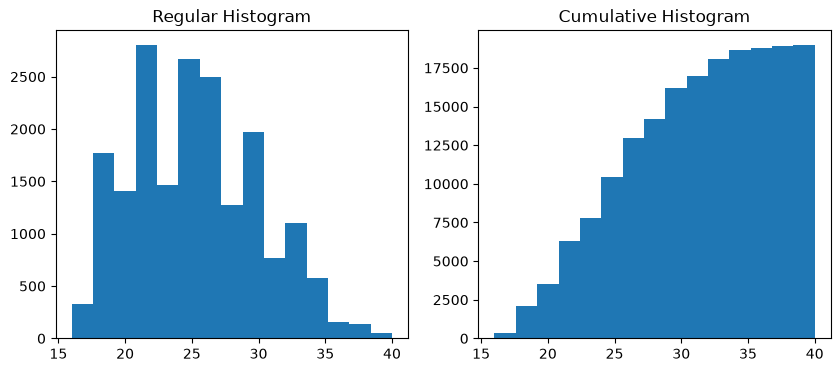

In [55]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(fifa_df['Age'], bins=15)
ax1.set_title('Regular Histogram')

ax2.hist(fifa_df['Age'], bins=15, cumulative=True)
ax2.set_title('Cumulative Histogram')

plt.show()

In [56]:
print(fifa_df['Weight'].unique()[:20])

['159lbs' '183lbs' '192lbs' '154lbs' '150lbs' '176lbs' '161lbs' '201lbs'
 '157lbs' '152lbs' '203lbs' '187lbs' '185lbs' '212lbs' '179lbs' '181lbs'
 '165lbs' '190lbs' '196lbs' '163lbs']


In [57]:
# Find values of Weight that are in lbs
weight_lbs = fifa_df['Weight'].str.contains('lbs', na=False)

# Convert Weight where it is in lbs to kg
fifa_df.loc[weight_lbs, 'Weight'] = fifa_df.loc[weight_lbs, 'Weight'].str.replace('lbs', '').astype(float) * 0.453592

# Unify Weight column by removing 'kg' from the rest and converting to numeric
fifa_df.loc[~weight_lbs, 'Weight'] = fifa_df.loc[~weight_lbs, 'Weight'].str.replace('kg', '').astype(float)

# Assert Weight column is now fully numeric, no unit strings remain
assert fifa_df['Weight'].apply(lambda x: isinstance(x, float)).all()